 
# TP3 - Analyse en Composantes Principales (ACP)
**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3 
## Module: Analyse des Données - M1 IV
### Données du TP1: Enquête sur le choix du sport par ville

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Configuration pour affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams['figure.figsize'] = (12, 8)

## DONNÉES DU TP1
### Matrice X: 20 villes × 6 sports

In [2]:
# Données brutes du TP1
data = np.array([
    [1881.9, 96.8,  14.2, 25.2, 1135.5, 278.3],   # V1
    [3369.8, 96.8,  10.8, 51.6, 1331.7, 284.0],   # V2
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],   # V3
    [1862.1, 83.2,   8.8, 27.6,  972.6, 203.4],   # V4
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],   # V5
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],   # V6
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],   # V7
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],   # V8
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],   # V9
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],   # V10
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],   # V11
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],   # V12
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],   # V13
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],   # V14
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],   # V15
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],   # V16
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],   # V17
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],   # V18
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],   # V19
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]    # V20
])

# Noms des villes et variables
villes = [f'V{i}' for i in range(1, 21)]
sports = ['H.Ball', 'B.Ball', 'Tennis', 'Gym', 'Natation', 'F.Ball']
n_individus = 20
n_variables = 6

# Créer DataFrame avec noms
df_donnees = pd.DataFrame(data, index=villes, columns=sports)
print("="*80)
print("MATRICE DES DONNÉES X (20 villes × 6 sports)")
print("="*80)
print(df_donnees.round(1))
print(f"\nDimensions: {data.shape}")

MATRICE DES DONNÉES X (20 villes × 6 sports)
     H.Ball  B.Ball  Tennis   Gym  Natation  F.Ball
V1   1881.9    96.8    14.2  25.2    1135.5   278.3
V2   3369.8    96.8    10.8  51.6    1331.7   284.0
V3   4467.4   138.2     9.5  34.2    2346.1   312.3
V4   1862.1    83.2     8.8  27.6     972.6   203.4
V5   3499.8   287.0    11.5  49.4    2139.4   358.0
V6   3903.2   170.7     6.3  42.0    1935.2   292.9
V7   2620.7   129.5     4.2  16.8    1346.0   131.8
V8   3678.4   157.0     6.0  24.9    1682.6   194.2
V9   3840.5   187.9    10.2  39.6    1859.9   449.1
V10  2170.2   140.5    11.7  31.1    1351.1   256.5
V11  3920.4   128.0     7.2  25.5    1911.5    64.1
V12  2599.6    39.6     5.5  19.4    1050.8   172.5
V13  2828.5   211.3     9.9  21.8    1085.0   209.0
V14  2498.7   123.2     7.4  26.5    1086.2   153.5
V15  2685.1    41.2     2.3  10.6     812.5    89.8
V16  2739.3   100.7     6.6  22.0    1270.4   180.5
V17  1662.1    81.1    10.1  19.1     872.2   123.3
V18  2469.9   142.9

## EXERCICE 1 - Analyse du Nuage des Individus
### A) Questions 1 à 6

In [3]:
# STANDARDISATION (centrage et réduction)
scaler = StandardScaler()
data_std = scaler.fit_transform(data)

# CALCUL DE L'ACP
pca = PCA(n_components=3)
scores = pca.fit_transform(data_std)  # Coordonnées des individus sur les axes

# Valeurs propres et variance expliquée
eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_

print("\n" + "="*80)
print("RÉSULTATS DE L'ACP")
print("="*80)
print(f"\nValeurs propres: {eigenvalues.round(4)}")
print(f"Variance expliquée (%): {(variance_ratio*100).round(2)}")
print(f"Variance cumulée (%): {np.cumsum(variance_ratio*100).round(2)}")


RÉSULTATS DE L'ACP

Valeurs propres: [3.6694 1.4967 0.4977]
Variance expliquée (%): [58.1  23.7   7.88]
Variance cumulée (%): [58.1  81.8  89.68]


### A.1) Carré de la distance de chaque individu au centre

In [4]:
# Carré de la distance au centre du nuage
# Distance² = somme des carrés des coordonnées sur tous les axes
distances_carre = np.sum(scores**2, axis=1)

# Distances
distances = np.sqrt(distances_carre)

tab_distances = pd.DataFrame({
    'Individu': villes,
    'Distance²': distances_carre,
    'Distance': distances
})

print("\n" + "="*80)
print("A.1) CARRÉ DE LA DISTANCE DE CHAQUE INDIVIDU AU CENTRE")
print("="*80)
print(tab_distances.to_string(index=False))
print(f"\nSomme des distances²: {np.sum(distances_carre):.4f}")
print(f"Somme des distances: {np.sum(distances):.4f}")


A.1) CARRÉ DE LA DISTANCE DE CHAQUE INDIVIDU AU CENTRE
Individu  Distance²  Distance
      V1   5.187836  2.277682
      V2   4.175199  2.043330
      V3   9.393047  3.064808
      V4   3.244795  1.801331
      V5  14.195374  3.767675
      V6   5.519967  2.349461
      V7   3.688563  1.920563
      V8   2.175249  1.474872
      V9   8.297033  2.880457
     V10   1.762297  1.327515
     V11   4.057359  2.014289
     V12   4.220265  2.054328
     V13   1.804847  1.343446
     V14   1.287281  1.134584
     V15  11.302899  3.361978
     V16   1.255723  1.120590
     V17   6.614443  2.571856
     V18   5.628822  2.372514
     V19   6.824054  2.612289
     V20   6.976299  2.641268

Somme des distances²: 107.6113
Somme des distances: 44.1348


### A.2-3) Déduction sur l'inertie totale

In [5]:
print("\n" + "="*80)
print("A.2-3) DÉDUCTION")
print("="*80)
inertie_totale = np.sum(distances_carre)
print(f"""
La somme des distances au carré = Inertie totale du nuage = {inertie_totale:.4f}

Cette inertie mesure la dispersion globale du nuage de points.
C'est la somme des valeurs propres de la matrice de covariance.
L'ACP décompose cette inertie selon les axes principaux.

Inertie expliquée par Axe 1: {eigenvalues[0]:.4f} ({variance_ratio[0]*100:.2f}%)
Inertie expliquée par Axe 2: {eigenvalues[1]:.4f} ({variance_ratio[1]*100:.2f}%)
Inertie expliquée par Axe 3: {eigenvalues[2]:.4f} ({variance_ratio[2]*100:.2f}%)

Total: {np.sum(eigenvalues):.4f} (= inertie totale ✓)
""")


A.2-3) DÉDUCTION

La somme des distances au carré = Inertie totale du nuage = 107.6113

Cette inertie mesure la dispersion globale du nuage de points.
C'est la somme des valeurs propres de la matrice de covariance.
L'ACP décompose cette inertie selon les axes principaux.

Inertie expliquée par Axe 1: 3.6694 (58.10%)
Inertie expliquée par Axe 2: 1.4967 (23.70%)
Inertie expliquée par Axe 3: 0.4977 (7.88%)

Total: 5.6638 (= inertie totale ✓)



### A.4) Qualité de représentation de chaque individu (cos²)

In [6]:
# FORMULE: cos²(individu i sur axe k) = (coordonnée i,k)² / distance²(i)
cos2_indiv = (scores**2) / distances_carre.reshape(-1, 1)

# Créer le tableau
qualite_indiv = pd.DataFrame({
    'Individu': villes,
    'cos² Axe 1': cos2_indiv[:, 0],
    'cos² Axe 2': cos2_indiv[:, 1],
    'cos² Axe 3': cos2_indiv[:, 2],
    'Somme (vérif)': np.sum(cos2_indiv[:, :3], axis=1)
})

print("\n" + "="*80)
print("A.4) QUALITÉ DE REPRÉSENTATION DES INDIVIDUS")
print("="*80)
print(f"""
FORMULE: cos²(i,k) = (coordonnée de l'individu i sur l'axe k)² / distance²(i)

Interprétation:
- cos² proche de 1 → individu bien représenté sur cet axe
- cos² proche de 0 → individu mal représenté sur cet axe
- La somme des cos² sur les 3 axes = 1 pour chaque individu
""")
print(qualite_indiv.to_string(index=False))

print(f"""
\nINTERPRÉTATION DÉTAILLÉE:
""")
# Identifier les individus bien/mal représentés
for j in range(3):
    print(f"\nAxe {j+1}:")
    bien_rep = np.where(cos2_indiv[:, j] > 0.7)[0]
    mal_rep = np.where(cos2_indiv[:, j] < 0.3)[0]
    
    if len(bien_rep) > 0:
        print(f"  Bien représentés (cos² > 0.7): {[villes[i] for i in bien_rep]}")
    if len(mal_rep) > 0:
        print(f"  Mal représentés (cos² < 0.3): {[villes[i] for i in mal_rep]}")


A.4) QUALITÉ DE REPRÉSENTATION DES INDIVIDUS

FORMULE: cos²(i,k) = (coordonnée de l'individu i sur l'axe k)² / distance²(i)

Interprétation:
- cos² proche de 1 → individu bien représenté sur cet axe
- cos² proche de 0 → individu mal représenté sur cet axe
- La somme des cos² sur les 3 axes = 1 pour chaque individu

Individu  cos² Axe 1  cos² Axe 2  cos² Axe 3  Somme (vérif)
      V1    0.043348    0.910130    0.046522            1.0
      V2    0.452447    0.088984    0.458569            1.0
      V3    0.644868    0.247493    0.107639            1.0
      V4    0.593870    0.391284    0.014846            1.0
      V5    0.971540    0.002142    0.026317            1.0
      V6    0.702156    0.287751    0.010093            1.0
      V7    0.617806    0.254383    0.127811            1.0
      V8    0.041011    0.925780    0.033210            1.0
      V9    0.994179    0.000134    0.005687            1.0
     V10    0.007938    0.989139    0.002924            1.0
     V11    0.000007  

### A.5) Contribution de chaque individu à l'inertie des axes

In [7]:
# FORMULE: Contribution(i,k) = (coordonnée i,k)² / valeur propre k * 100
contrib_indiv = (scores**2) / eigenvalues * 100

tab_contrib_indiv = pd.DataFrame({
    'Individu': villes,
    'Contrib Axe 1 (%)': contrib_indiv[:, 0],
    'Contrib Axe 2 (%)': contrib_indiv[:, 1],
    'Contrib Axe 3 (%)': contrib_indiv[:, 2]
})

print("\n" + "="*80)
print("A.5) CONTRIBUTION DES INDIVIDUS À L'INERTIE DES AXES")
print("="*80)
print(f"""
FORMULE: Contribution(i,k) = (coordonnée i,k)² / λk × 100

où λk = valeur propre de l'axe k

Contribution moyenne par individu = 100/{n_individus} = {100/n_individus:.2f}%
""")
print(tab_contrib_indiv.to_string(index=False))

print(f"""
\nINTERPRÉTATION DÉTAILLÉE:
""")
for j in range(3):
    print(f"\nAxe {j+1}:")
    top_contrib = np.argsort(contrib_indiv[:, j])[-3:][::-1]
    print(f"  Top 3 contributeurs: ", end="")
    for idx in top_contrib:
        print(f"{villes[idx]} ({contrib_indiv[idx, j]:.2f}%), ", end="")
    print()
    # Vérifier que la somme = 100
    somme_contrib = np.sum(contrib_indiv[:, j])
    print(f"  Somme des contributions: {somme_contrib:.2f}% (vérification ✓)")


A.5) CONTRIBUTION DES INDIVIDUS À L'INERTIE DES AXES

FORMULE: Contribution(i,k) = (coordonnée i,k)² / λk × 100

où λk = valeur propre de l'axe k

Contribution moyenne par individu = 100/20 = 5.00%

Individu  Contrib Axe 1 (%)  Contrib Axe 2 (%)  Contrib Axe 3 (%)
      V1           6.128526         315.470382          48.496344
      V2          51.481380          24.823082         384.718209
      V3         165.075284         155.324056         203.159467
      V4          52.515037          84.829734           9.679469
      V5         375.848273           2.032031          75.066646
      V6         105.627075         106.125951          11.194814
      V7          62.103237          62.692371          94.729549
      V8           2.431137         134.550561          14.515539
      V9         224.797991           0.074025           9.481438
     V10           0.381229         116.467602           1.035254
     V11           0.000818         262.214420          26.684236
     V12

### A.6) Individus mal représentés sur chaque axe

In [8]:
seuil = 0.5

print("\n" + "="*80)
print(f"A.6) INDIVIDUS MAL REPRÉSENTÉS (cos² < {seuil})")
print("="*80)

for axe in range(3):
    print(f"\nAxe {axe+1}:")
    mal_rep = np.where(cos2_indiv[:, axe] < seuil)[0]
    
    if len(mal_rep) > 0:
        for idx in mal_rep:
            signe = "+" if scores[idx, axe] > 0 else "-"
            print(f"  {villes[idx]}: cos²={cos2_indiv[idx, axe]:.4f}, signe = {signe}, coord = {scores[idx, axe]:.4f}")
    else:
        print(f"  Aucun individu mal représenté sur cet axe")


A.6) INDIVIDUS MAL REPRÉSENTÉS (cos² < 0.5)

Axe 1:
  V1: cos²=0.0433, signe = -, coord = -0.4742
  V2: cos²=0.4524, signe = +, coord = 1.3744
  V8: cos²=0.0410, signe = +, coord = 0.2987
  V10: cos²=0.0079, signe = +, coord = 0.1183
  V11: cos²=0.0000, signe = +, coord = 0.0055
  V13: cos²=0.0140, signe = -, coord = -0.1587
  V18: cos²=0.0966, signe = +, coord = 0.7373

Axe 2:
  V2: cos²=0.0890, signe = +, coord = 0.6095
  V3: cos²=0.2475, signe = -, coord = -1.5247
  V4: cos²=0.3913, signe = +, coord = 1.1268
  V5: cos²=0.0021, signe = +, coord = 0.1744
  V6: cos²=0.2878, signe = -, coord = -1.2603
  V7: cos²=0.2544, signe = -, coord = -0.9687
  V9: cos²=0.0001, signe = +, coord = 0.0333
  V12: cos²=0.0254, signe = -, coord = -0.3276
  V13: cos²=0.1705, signe = +, coord = 0.5547
  V14: cos²=0.0194, signe = +, coord = 0.1580
  V15: cos²=0.1096, signe = -, coord = -1.1128
  V16: cos²=0.0913, signe = -, coord = -0.3385
  V17: cos²=0.2453, signe = +, coord = 1.2737
  V19: cos²=0.1502, s

## EXERCICE 1 - B) Analyse du Nuage des Variables

### B.1) Coordonnées des variables sur les axes principaux

In [9]:
# Vecteurs propres (loadings)
loadings = pca.components_.T  # p × k (6 × 3)

# Coordonnées des variables = loadings * sqrt(valeurs propres)
var_coords = loadings * np.sqrt(eigenvalues)

tab_var_coords = pd.DataFrame({
    'Variable': sports,
    'Coord Axe 1': var_coords[:, 0],
    'Coord Axe 2': var_coords[:, 1],
    'Coord Axe 3': var_coords[:, 2]
})

print("\n" + "="*80)
print("B.1) COORDONNÉES DES VARIABLES SUR LES AXES PRINCIPAUX")
print("="*80)
print(tab_var_coords.round(4).to_string(index=False))

print(f"""
Note: Ces coordonnées correspondent aux corrélations entre les variables
et les composantes principales (jusqu'au coefficient √λ).
""")


B.1) COORDONNÉES DES VARIABLES SUR LES AXES PRINCIPAUX
Variable  Coord Axe 1  Coord Axe 2  Coord Axe 3
  H.Ball       0.7215      -0.6768      -0.1189
  B.Ball       0.8081       0.0552       0.6177
  Tennis       0.5141       0.7938      -0.1895
     Gym       0.9081       0.1651      -0.2126
Natation       0.8233      -0.5040      -0.1442
  F.Ball       0.8538       0.3523      -0.0049

Note: Ces coordonnées correspondent aux corrélations entre les variables
et les composantes principales (jusqu'au coefficient √λ).



### B.2) Cercles de corrélation

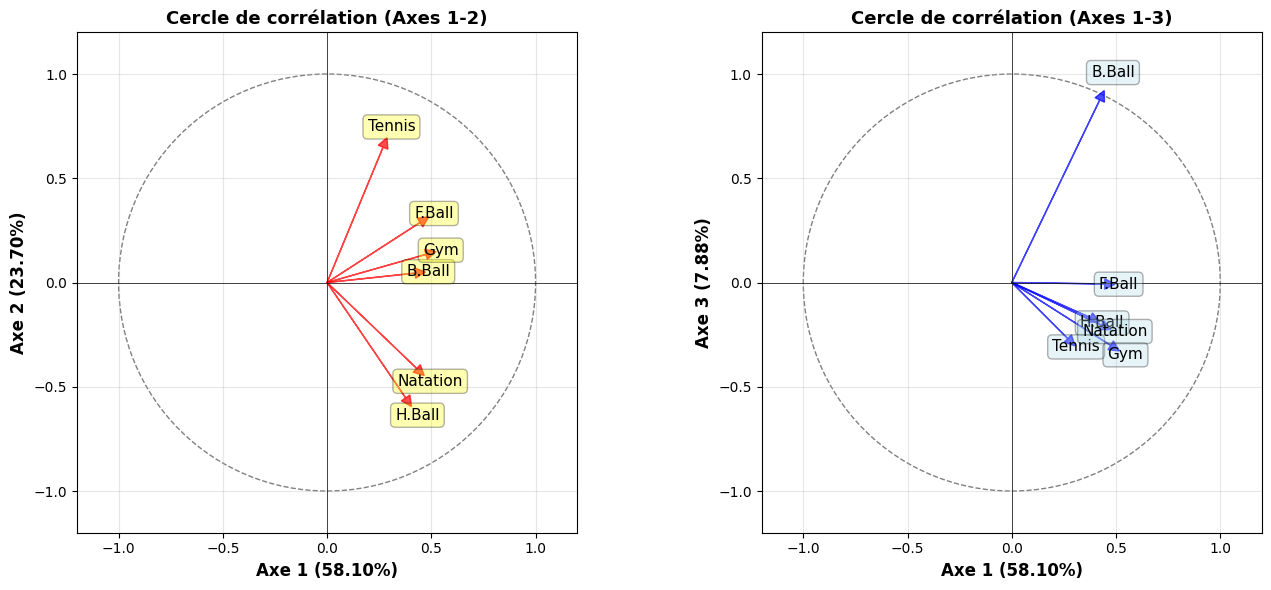


B.2) CERCLES DE CORRÉLATION ENREGISTRÉS


In [20]:
# Créer les cercles de corrélation normalisés
var_coords_norm = loadings  # Corrélations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Cercle 1: Axes 1-2
ax1.set_aspect('equal')
cercle1 = plt.Circle((0, 0), 1, color='grey', linestyle='--', linewidth=1, fill=False)
ax1.add_patch(cercle1)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)

for i, var in enumerate(sports):
    ax1.arrow(0, 0, var_coords_norm[i, 0], var_coords_norm[i, 1], 
              head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7)
    # Placer les labels légèrement en dehors
    offset = 1.15
    ax1.text(var_coords_norm[i, 0]*offset, var_coords_norm[i, 1]*offset, var, 
             fontsize=11, ha='center', va='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_xlabel(f'Axe 1 ({variance_ratio[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'Axe 2 ({variance_ratio[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax1.set_title('Cercle de corrélation (Axes 1-2)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cercle 2: Axes 1-3
ax2.set_aspect('equal')
cercle2 = plt.Circle((0, 0), 1, color='grey', linestyle='--', linewidth=1, fill=False)
ax2.add_patch(cercle2)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)

for i, var in enumerate(sports):
    ax2.arrow(0, 0, var_coords_norm[i, 0], var_coords_norm[i, 2], 
              head_width=0.05, head_length=0.05, fc='blue', ec='blue', alpha=0.7)
    offset = 1.15
    ax2.text(var_coords_norm[i, 0]*offset, var_coords_norm[i, 2]*offset, var, 
             fontsize=11, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.3))

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel(f'Axe 1 ({variance_ratio[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'Axe 3 ({variance_ratio[2]*100:.2f}%)', fontsize=12, fontweight='bold')
ax2.set_title('Cercle de corrélation (Axes 1-3)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("B.2) CERCLES DE CORRÉLATION ENREGISTRÉS")
print("="*80)

### B.3) Interprétation des cercles de corrélation

In [12]:
print("\n" + "="*80)
print("B.3) INTERPRÉTATION DES CERCLES DE CORRÉLATION")
print("="*80)
print("""
Analyse du nuage des variables:

1. POSITION PAR RAPPORT AU CERCLE:
   - Variables proches du cercle → bien représentées dans le plan factoriel
   - Variables au centre → mal représentées

2. DISTANCE ENTRE VARIABLES:
   - Variables proches → fortement corrélées positivement
   - Variables opposées (angle 180°) → fortement corrélées négativement
   - Variables orthogonales (angle 90°) → non corrélées (indépendantes)

3. DIRECTION PAR RAPPORT AUX AXES:
   - Variable alignée avec Axe 1 → fortement corrélée avec CP1
   - Variable alignée avec Axe 2 → fortement corrélée avec CP2
""")

# Analyse spécifique
print("\nANALYSE SPÉCIFIQUE AUX DONNÉES:")
for i, var in enumerate(sports):
    dist_cercle = np.sqrt(var_coords_norm[i, 0]**2 + var_coords_norm[i, 1]**2)
    print(f"\n{var}:")
    print(f"  Distance au centre: {dist_cercle:.4f}")
    if dist_cercle > 0.8:
        print(f"  → BIEN représentée dans le plan (Axes 1-2)")
    else:
        print(f"  → MAL représentée dans le plan (Axes 1-2)")


B.3) INTERPRÉTATION DES CERCLES DE CORRÉLATION

Analyse du nuage des variables:

1. POSITION PAR RAPPORT AU CERCLE:
   - Variables proches du cercle → bien représentées dans le plan factoriel
   - Variables au centre → mal représentées

2. DISTANCE ENTRE VARIABLES:
   - Variables proches → fortement corrélées positivement
   - Variables opposées (angle 180°) → fortement corrélées négativement
   - Variables orthogonales (angle 90°) → non corrélées (indépendantes)

3. DIRECTION PAR RAPPORT AUX AXES:
   - Variable alignée avec Axe 1 → fortement corrélée avec CP1
   - Variable alignée avec Axe 2 → fortement corrélée avec CP2


ANALYSE SPÉCIFIQUE AUX DONNÉES:

H.Ball:
  Distance au centre: 0.6693
  → MAL représentée dans le plan (Axes 1-2)

B.Ball:
  Distance au centre: 0.4243
  → MAL représentée dans le plan (Axes 1-2)

Tennis:
  Distance au centre: 0.7022
  → MAL représentée dans le plan (Axes 1-2)

Gym:
  Distance au centre: 0.4929
  → MAL représentée dans le plan (Axes 1-2)

Natation:

### B.4) Caractérisation des axes

In [13]:
print("\n" + "="*80)
print("B.4) CARACTÉRISATION DES AXES PRINCIPAUX")
print("="*80)

# Axe 1
print("\nAXE 1:")
coord_abs_axe1 = np.abs(var_coords_norm[:, 0])
top_vars_axe1 = np.argsort(coord_abs_axe1)[-3:][::-1]
for idx in top_vars_axe1:
    print(f"  {sports[idx]}: corrélation = {var_coords_norm[idx, 0]:.4f}")

# Axe 2
print("\nAXE 2:")
coord_abs_axe2 = np.abs(var_coords_norm[:, 1])
top_vars_axe2 = np.argsort(coord_abs_axe2)[-3:][::-1]
for idx in top_vars_axe2:
    print(f"  {sports[idx]}: corrélation = {var_coords_norm[idx, 1]:.4f}")

print("""
\nINTERPRÉTATION:
- Axe 1 représente essentiellement les variables les plus corrélées avec lui
- Axe 2 représente un contraste indépendant du premier axe
- Ces axes sont des combinaisons linéaires des variables originales
""")


B.4) CARACTÉRISATION DES AXES PRINCIPAUX

AXE 1:
  Gym: corrélation = 0.4741
  F.Ball: corrélation = 0.4457
  Natation: corrélation = 0.4298

AXE 2:
  Tennis: corrélation = 0.6489
  H.Ball: corrélation = -0.5533
  Natation: corrélation = -0.4120


INTERPRÉTATION:
- Axe 1 représente essentiellement les variables les plus corrélées avec lui
- Axe 2 représente un contraste indépendant du premier axe
- Ces axes sont des combinaisons linéaires des variables originales



### B.5) Qualité de représentation des variables (cos²)

In [14]:
# FORMULE: cos²(variable j sur axe k) = r²(var j, axe k)
# où r = corrélation entre la variable et la composante
var_cos2 = var_coords_norm**2

tab_var_cos2 = pd.DataFrame({
    'Variable': sports,
    'cos² Axe 1': var_cos2[:, 0],
    'cos² Axe 2': var_cos2[:, 1],
    'cos² Axe 3': var_cos2[:, 2],
    'Somme (vérif)': np.sum(var_cos2[:, :3], axis=1)
})

print("\n" + "="*80)
print("B.5) QUALITÉ DE REPRÉSENTATION DES VARIABLES")
print("="*80)
print(f"""
FORMULE: cos²(j,k) = (corrélation entre var j et axe k)²
         = (coordonnée j,k / norme)²

Interprétation:
- cos² proche de 1 → variable bien représentée sur cet axe
- cos² proche de 0 → variable mal représentée sur cet axe  
- La somme des cos² sur les 3 axes = 1 pour chaque variable
(car les variables originales sont dans ℝ³ après standardisation)
""")
print(tab_var_cos2.round(4).to_string(index=False))

print(f"""
\nINTERPRÉTATION DÉTAILLÉE:
""")
for j in range(3):
    print(f"\nAxe {j+1}:")
    bien_rep = np.where(var_cos2[:, j] > 0.7)[0]
    mal_rep = np.where(var_cos2[:, j] < 0.3)[0]
    
    if len(bien_rep) > 0:
        print(f"  Bien représentées (cos² > 0.7): {[sports[i] for i in bien_rep]}")
    if len(mal_rep) > 0:
        print(f"  Mal représentées (cos² < 0.3): {[sports[i] for i in mal_rep]}")


B.5) QUALITÉ DE REPRÉSENTATION DES VARIABLES

FORMULE: cos²(j,k) = (corrélation entre var j et axe k)²
         = (coordonnée j,k / norme)²

Interprétation:
- cos² proche de 1 → variable bien représentée sur cet axe
- cos² proche de 0 → variable mal représentée sur cet axe  
- La somme des cos² sur les 3 axes = 1 pour chaque variable
(car les variables originales sont dans ℝ³ après standardisation)

Variable  cos² Axe 1  cos² Axe 2  cos² Axe 3  Somme (vérif)
  H.Ball      0.1419      0.3061      0.0284         0.4764
  B.Ball      0.1780      0.0020      0.7668         0.9468
  Tennis      0.0720      0.4210      0.0722         0.5652
     Gym      0.2247      0.0182      0.0908         0.3338
Natation      0.1847      0.1697      0.0418         0.3962
  F.Ball      0.1987      0.0829      0.0000         0.2816


INTERPRÉTATION DÉTAILLÉE:


Axe 1:
  Mal représentées (cos² < 0.3): ['H.Ball', 'B.Ball', 'Tennis', 'Gym', 'Natation', 'F.Ball']

Axe 2:
  Mal représentées (cos² < 0.3): ['B.B

### B.6) Contribution des variables à l'inertie des axes

In [15]:
# FORMULE: Contribution(j,k) = cos²(j,k) = (corrélation)²
# Normalisée par la somme des contributions
var_contrib = var_cos2 * 100  # Ou normalisé si on veut que la somme fasse 100

tab_var_contrib = pd.DataFrame({
    'Variable': sports,
    'Contrib Axe 1 (%)': var_contrib[:, 0],
    'Contrib Axe 2 (%)': var_contrib[:, 1],
    'Contrib Axe 3 (%)': var_contrib[:, 2]
})

print("\n" + "="*80)
print("B.6) CONTRIBUTION DES VARIABLES À L'INERTIE DES AXES")
print("="*80)
print(f"""
FORMULE: Contribution(j,k) = cos²(j,k) × 100 / n_variables
                           = (corrélation j,k)² × 100 / {n_variables}

Contribution moyenne par variable = 100/{n_variables} = {100/n_variables:.2f}%
""")
print(tab_var_contrib.round(2).to_string(index=False))

print(f"""
\nINTERPRÉTATION DÉTAILLÉE:
""")
for j in range(3):
    print(f"\nAxe {j+1}:")
    top_contrib = np.argsort(var_contrib[:, j])[-2:][::-1]
    print(f"  Top contributeurs: ", end="")
    for idx in top_contrib:
        print(f"{sports[idx]} ({var_contrib[idx, j]:.2f}%), ", end="")
    print()


B.6) CONTRIBUTION DES VARIABLES À L'INERTIE DES AXES

FORMULE: Contribution(j,k) = cos²(j,k) × 100 / n_variables
                           = (corrélation j,k)² × 100 / 6

Contribution moyenne par variable = 100/6 = 16.67%

Variable  Contrib Axe 1 (%)  Contrib Axe 2 (%)  Contrib Axe 3 (%)
  H.Ball              14.19              30.61               2.84
  B.Ball              17.80               0.20              76.68
  Tennis               7.20              42.10               7.22
     Gym              22.47               1.82               9.08
Natation              18.47              16.97               4.18
  F.Ball              19.87               8.29               0.00


INTERPRÉTATION DÉTAILLÉE:


Axe 1:
  Top contributeurs: Gym (22.47%), F.Ball (19.87%), 

Axe 2:
  Top contributeurs: Tennis (42.10%), H.Ball (30.61%), 

Axe 3:
  Top contributeurs: B.Ball (76.68%), Gym (9.08%), 


### B.7) Représentation jointe: individus et variables

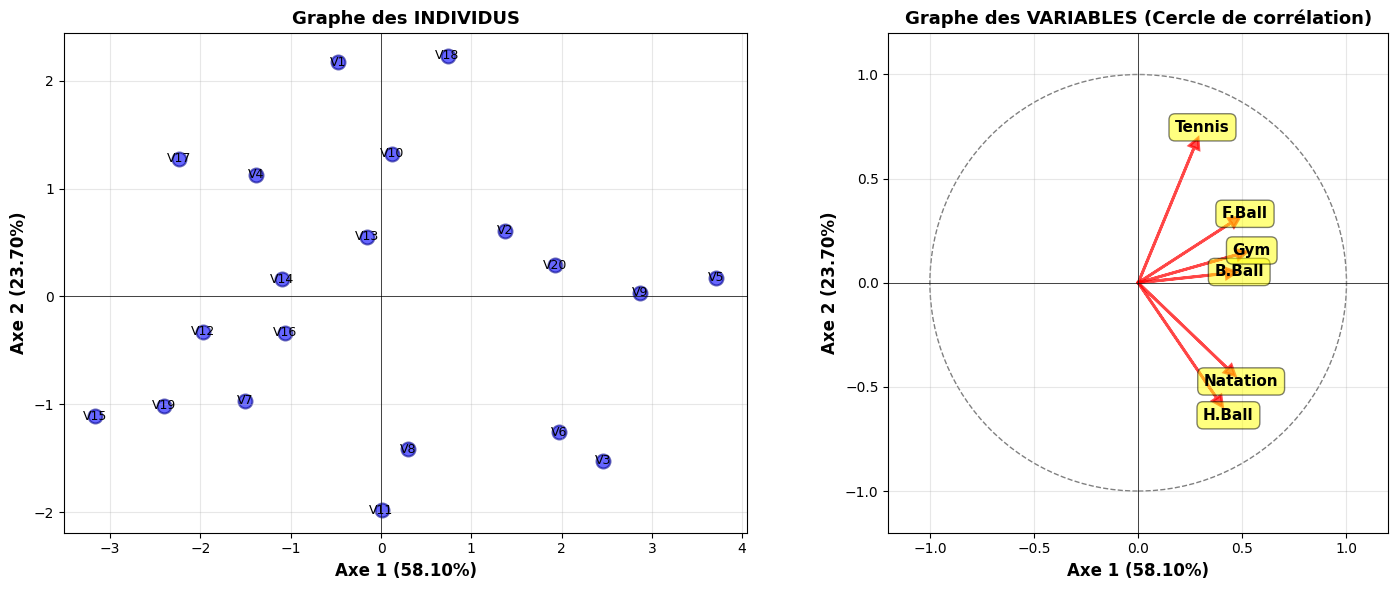


B.7) GRAPHES JOINTS ENREGISTRÉS


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphe 1: Individus
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.scatter(scores[:, 0], scores[:, 1], c='blue', s=100, alpha=0.6, edgecolors='darkblue', linewidth=1.5)

for i in range(20):
    ax1.annotate(villes[i], (scores[i, 0], scores[i, 1]), 
                fontsize=9, ha='center', va='center')

ax1.set_xlabel(f'Axe 1 ({variance_ratio[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'Axe 2 ({variance_ratio[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax1.set_title('Graphe des INDIVIDUS', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('auto')

# Graphe 2: Variables
ax2.set_aspect('equal')
cercle = plt.Circle((0, 0), 1, color='grey', linestyle='--', linewidth=1, fill=False)
ax2.add_patch(cercle)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)

for i, var in enumerate(sports):
    ax2.arrow(0, 0, var_coords_norm[i, 0], var_coords_norm[i, 1], 
              head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7, linewidth=2)
    offset = 1.15
    ax2.text(var_coords_norm[i, 0]*offset, var_coords_norm[i, 1]*offset, var, 
             fontsize=11, ha='center', va='center', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.5))

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel(f'Axe 1 ({variance_ratio[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'Axe 2 ({variance_ratio[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax2.set_title('Graphe des VARIABLES (Cercle de corrélation)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("B.7) GRAPHES JOINTS ENREGISTRÉS")
print("="*80)

### B.8) BIPLOT - Carte d'analyse des correspondances

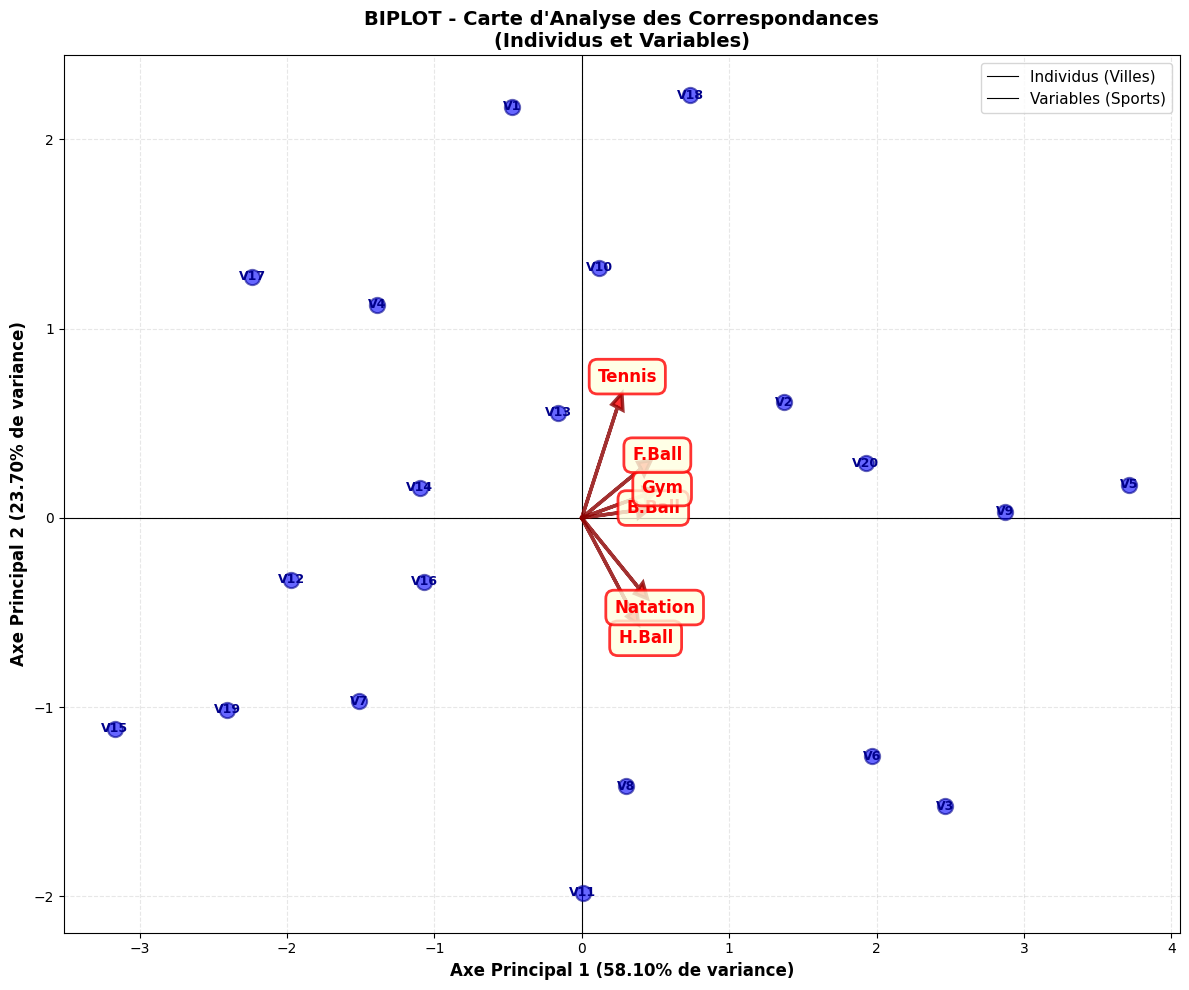


B.8) BIPLOT ENREGISTRÉ

Le BIPLOT permet une interprétation simultanée des individus et des variables:

1. INDIVIDUS (points bleus):
   - Position relative → ressemblance/dissemblance entre villes
   - Individus proches → profils de sports similaires

2. VARIABLES (flèches rouges):
   - Direction → corrélation avec les axes
   - Longueur → force de corrélation

3. RELATION INDIVIDU-VARIABLE:
   - Si un individu est dans la direction d'une variable → valeur élevée
   - Si en direction opposée → valeur faible



In [18]:
plt.figure(figsize=(12, 10))

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Individus en BLEU
plt.scatter(scores[:, 0], scores[:, 1], c='blue', s=120, alpha=0.6, 
            edgecolors='darkblue', linewidth=1.5, label='Individus (villes)', zorder=3)

for i in range(20):
    plt.annotate(villes[i], (scores[i, 0], scores[i, 1]), 
                fontsize=9, ha='center', va='center', color='darkblue', fontweight='bold')

# Variables en ROUGE (avec flèches depuis l'origine)
for i, var in enumerate(sports):
    plt.arrow(0, 0, var_coords_norm[i, 0]*0.9, var_coords_norm[i, 1]*0.9, 
              head_width=0.08, head_length=0.08, fc='red', ec='darkred', 
              alpha=0.8, linewidth=2.5, zorder=2)
    
    # Label des variables
    offset = 1.15
    plt.text(var_coords_norm[i, 0]*offset, var_coords_norm[i, 1]*offset, var, 
             fontsize=12, ha='center', va='center', color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                      edgecolor='red', linewidth=2, alpha=0.8))

plt.xlabel(f'Axe Principal 1 ({variance_ratio[0]*100:.2f}% de variance)', 
           fontsize=12, fontweight='bold')
plt.ylabel(f'Axe Principal 2 ({variance_ratio[1]*100:.2f}% de variance)', 
           fontsize=12, fontweight='bold')
plt.title('BIPLOT - Carte d\'Analyse des Correspondances\n(Individus et Variables)', 
          fontsize=14, fontweight='bold')
plt.legend(['Individus (Villes)', 'Variables (Sports)'], loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

print("\n" + "="*80)
print("B.8) BIPLOT ENREGISTRÉ")
print("="*80)
print("""
Le BIPLOT permet une interprétation simultanée des individus et des variables:

1. INDIVIDUS (points bleus):
   - Position relative → ressemblance/dissemblance entre villes
   - Individus proches → profils de sports similaires

2. VARIABLES (flèches rouges):
   - Direction → corrélation avec les axes
   - Longueur → force de corrélation

3. RELATION INDIVIDU-VARIABLE:
   - Si un individu est dans la direction d'une variable → valeur élevée
   - Si en direction opposée → valeur faible
""")